In [1]:
from utils.utils import DataLoader, DopplerDataset, plot_learning_curves, plot_multiple_learning_curves
from networks.model import Network_Class
import numpy as np
import matplotlib.pyplot as plt
import yaml
import os

# Load Data
base_path = "/Volumes/HIP_BACKUP/MEMOIRE/Code/MyDB2"
all = [f"NewExp{i}" for i in range(1, 51)]


In [3]:
l_exp = [f"Regression/ResNet_Folds_debug{i}" for i in range(1, 4)]
folds = list(range(1, 2))
data_loader = DataLoader(base_path, exp_list=all)

for exp in l_exp :
    for fold in folds :
        print(f"🔔 Starting {exp} fold {fold}")
        stream = open(f"exp_list/{exp}.yaml", 'r')
        param  = yaml.safe_load(stream)
        param["TRAINING"]["DEVICE"] = 'mps'
        param["DATASET"]["FOLD_NUMBER"] = fold

        resultsPath = os.path.join("results", exp, f"fold{fold}")

        # Create the directory
        if not os.path.exists(resultsPath):
            os.makedirs(resultsPath)

        myNetwork = Network_Class(data_loader, param, resultsPath, sub_sample_factor=1)

        #myNetwork.visualize_data_augmentation()

        # Train the network
        train_losses, val_losses =  myNetwork.train()

        # Test the network
        #myNetwork.loadWeight()
        #myNetwork.test(fold)




🔄 Chargement des données: 100%|██████████| 50/50 [00:00<00:00, 50.11exp/s]


🔔 Starting Regression/ResNet_Folds_debug1 fold 1

             DOPPLER DATASET INITIALIZATION SUMMARY
→ Active Antenna 2         : False
→ Active Phase             : False
→ Use previous frames      : False
→ Fold number              : 1
→ Total experiments        : 50
→ Dataset sizes (samples) :
   • Train set             : 40000
   • Validation set        : 5000
   • Test set              : 5000
→ Final selected dataset   : 50000 samples


                 NETWORK INITIALIZATION SUMMARY
→ Device                  : mps
→ Results path            : results/Regression/ResNet_Folds_debug1/fold1
→ Epochs                  : 20
→ Learning rate           : 0.0001
→ Batch size              : 16
→ Prediction type         : regression
→ Data augmentation       : False



🟢 Epoch 1/20: 100%|██████████| 2500/2500 [32:00<00:00,  1.12batch/s, loss=0.3433]

✅ Epoch 1/20 | Train Loss: 0.2356 | Val Loss: 0.1141
Model saved


🟢 Epoch 1/20: 100%|██████████| 2500/2500 [33:41<00:00,  1.24batch/s, loss=0.3433]


KeyboardInterrupt: 

In [14]:
all_train_losses = []
all_val_losses = []

exp = "Regression/ResNet_Folds_OneCycleLR"
resultsPath = os.path.join("results", exp)
folds = [2,3,5,8] #list(range(1, 9))

for fold in folds :
    train_losses = np.load(os.path.join(resultsPath, f"fold{fold}", "train_losses.npy"))
    val_losses = np.load(os.path.join(resultsPath, f"fold{fold}", "val_losses.npy"))
    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)

all_train_losses = np.array(all_train_losses)
all_val_losses = np.array(all_val_losses)

plot_multiple_learning_curves(all_train_losses, all_val_losses, resultsPath)


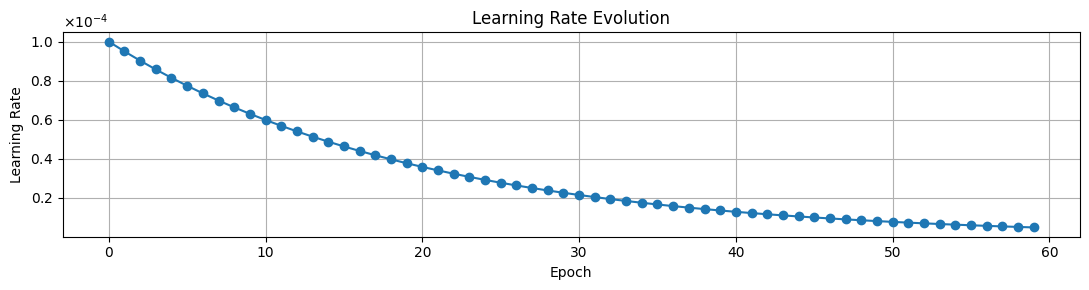

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# Paramètres donnés
initial_lr = 0.0001
gamma = 0.95
epochs = 60

# Calcul du LR pour chaque epoch
lr_values = [initial_lr * (gamma ** epoch) for epoch in range(epochs)]

# Tracé
plt.figure(figsize=(11, 3))
plt.plot(range(epochs), lr_values, marker='o')
plt.title("Learning Rate Evolution")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)
# Activation de la notation scientifique pour l'axe y
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.tight_layout()
plt.show()


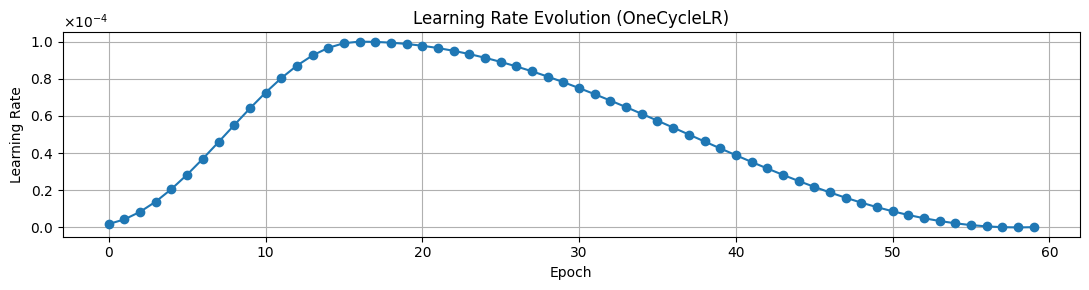

In [12]:
import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import OneCycleLR
import torch.nn as nn

# Paramètres
epochs = 60
lr_start = 1e-6
max_lr = 1e-4
steps_per_epoch = 1  # pour visualisation simple : 1 update par epoch
total_steps = steps_per_epoch * epochs

# Dummy model
model = nn.Linear(10, 1)
optimizer = Adam(model.parameters(), lr=lr_start)

# Scheduler OneCycleLR
scheduler = OneCycleLR(
    optimizer,
    max_lr=max_lr,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    anneal_strategy="cos",
    div_factor=max_lr / lr_start  # pour respecter le lr de départ donné
)

# Simuler les updates
lr_values = []
for step in range(total_steps):
    scheduler.step()
    lr_values.append(optimizer.param_groups[0]['lr'])

# Tracer
plt.figure(figsize=(11, 3))
plt.plot(range(epochs), lr_values, marker='o')
plt.title("Learning Rate Evolution (OneCycleLR)")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.tight_layout()
plt.show()


[0.21781168 0.12509687 0.09978905 0.0813962  0.06718481 0.0534143
 0.04455712 0.03694669 0.0301966  0.02519404 0.02131605 0.01830179
 0.01590528 0.01441121 0.01311162 0.01180133 0.01042128 0.01006744
 0.00924461 0.0085914  0.00801811 0.00796581 0.00730123 0.00683955
 0.00679891 0.00620576 0.00614238 0.0058533  0.00554102 0.00536483
 0.00520231 0.0050432  0.004891   0.00469631 0.00450984 0.00427142
 0.00430117 0.00399453 0.00408559 0.00392924 0.0037885  0.00361585
 0.00344904 0.00342522 0.00337998 0.00333943 0.00321741 0.00310227
 0.00301057 0.00299436 0.00297015 0.0029347  0.00287005 0.0025985
 0.00271408 0.00257497 0.00251765 0.00251999 0.00247224 0.00239697
 0.00234764 0.00232305 0.00235745 0.00215435 0.00215617 0.00221304
 0.00217299 0.00211823 0.00208327 0.00205418 0.00202825 0.00208257
 0.00193489 0.00190454 0.00191252 0.00179261 0.00178647 0.00177185
 0.00176846 0.00167569 0.00180463 0.00172116 0.00166666 0.00164726
 0.00168384 0.00161898 0.0016146  0.00165688 0.00151961 0.001537

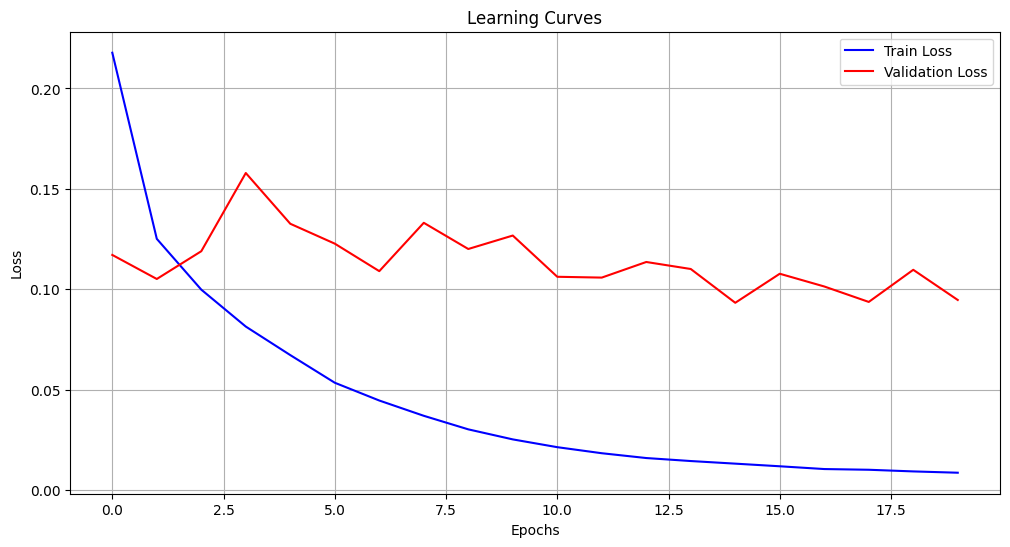

In [2]:
exp = "Regression/ResNet_Folds_Simple/fold5"
resultsPath = os.path.join("results", exp)

# Load learning curves
train_losses = np.load(os.path.join(resultsPath, "train_losses.npy"))
val_losses = np.load(os.path.join(resultsPath, "val_losses.npy"))
print(train_losses)
print(val_losses)

# Crop to only 20 epochs
train_losses = train_losses[:20]
val_losses = val_losses[:20]

plot_learning_curves(train_losses, val_losses, resultsPath, file_name="learning_curves_20epochs")